In [82]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

#Quaternion utilities

def hat(v):
    v = np.asarray(v).reshape(3,)
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

def unhat(S):
    return 0.5 * np.array([S[2,1]-S[1,2],
                           S[0,2]-S[2,0],
                           S[1,0]-S[0,1]])

H = np.vstack([np.zeros((1,3)), np.eye(3)])

Tquat = np.block([
    [np.array([[1]]), np.zeros((1,3))],
    [np.zeros((3,1)), -np.eye(3)]
])

def L(q):
    q = np.asarray(q)
    q0, qv = q[0], q[1:4]
    top = np.hstack([q0, -qv])
    bottom = np.hstack([qv.reshape(3,1), q0*np.eye(3) + hat(qv)])
    return np.vstack([top, bottom])

def R(q):
    q = np.asarray(q)
    return np.block([
        [q[0], -q[1:4]],
        [q[1:4].reshape(3,1), q[0]*np.eye(3) - hat(q[1:4])]
    ])

def G(q):
    return L(q) @ H

def Q(q):
    q = np.asarray(q)
    q = q / np.linalg.norm(q)
    q0, q1, q2, q3 = q
    return np.array([
        [1-2*(q2**2+q3**2), 2*(q1*q2-q0*q3), 2*(q0*q2+q1*q3)],
        [2*(q1*q2+q0*q3), 1-2*(q1**2+q3**2), 2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2), 2*(q0*q1+q2*q3), 1-2*(q1**2+q2**2)]
    ])

def expq(phi):
    phi = np.asarray(phi)
    theta = np.linalg.norm(phi)
    if theta < 1e-8:
        return np.hstack([1.0, phi])
    return np.hstack([np.cos(theta), phi * np.sin(theta)/theta])

def logq(q):
    q = np.asarray(q)
    q = q / np.linalg.norm(q)

    if q[0] < 0:
        q = -q

    theta = np.arccos(np.clip(q[0], -1.0, 1.0))
    s = np.linalg.norm(q[1:4])

    if s < 1e-8:
        return np.zeros(3)

    return theta * q[1:4] / s

def qconj(q):
    return Tquat @ q

def qmult(q1, q2):
    return L(q1) @ q2

def normalize_quat(q):
    n = np.linalg.norm(q)
    if not np.isfinite(n) or n < 1e-12:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / n

def attitude_error_deg(q):
    # logq uses half-angle convention, so physical angle = 2*||logq(q)||
    return np.degrees(2*np.linalg.norm(logq(q)))


In [83]:
#########  Orbit Model  ###########
mu_km = 398600.0          # km^3/s^2
mu = mu_km * 1e9          # m^3/s^2, for torque equations
earth_radius_km = 6371.0

def two_body(t, state):
    r = state[0:3]
    v = state[3:6]
    r_norm = np.linalg.norm(r)
    a = -mu_km * r / r_norm**3
    return np.hstack((v, a))

# Approximate TESS orbital radii
rp_km = 108000.0
ra_km = 373000.0

a_km = 0.5 * (rp_km + ra_km)
e = (ra_km - rp_km) / (ra_km + rp_km)

# Start at perigee in the x direction
r0_orbit = np.array([rp_km, 0.0, 0.0])
v_perigee = np.sqrt(mu_km * (2/np.linalg.norm(r0_orbit) - 1/a_km))
v0_orbit = np.array([0.0, v_perigee, 0.0])

orbit_state0 = np.hstack((r0_orbit, v0_orbit))

T_orbit = 2*np.pi*np.sqrt(a_km**3/mu_km)

print(f"TESS-like orbit period from chosen rp/ra: {T_orbit/86400:.2f} days")
print(f"Eccentricity: {e:.3f}")

num_orbits = 3
N = 2500
t_span = (0.0, num_orbits*T_orbit)
t_eval = np.linspace(t_span[0], t_span[1], N)
dt = t_eval[1] - t_eval[0]

orbit_sol = solve_ivp(
    two_body,
    t_span,
    orbit_state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

r_hist_km = orbit_sol.y[0:3, :]
v_hist_km_s = orbit_sol.y[3:6, :]

# Convert to meters for torque equations
r_hist = 1000.0 * r_hist_km

TESS-like orbit period from chosen rp/ra: 13.59 days
Eccentricity: 0.551


In [84]:
#########  Spacecraft Model  ###########
J = np.diag([132.56, 101.64, 89.61]) #Inertia Matrix

# Solar radiation pressure at ~1 AU from lecture notes
P_srp = 4.5e-6       # Pa = N/m^2

# Reflectivity coefficient
Cr = 1.5

# Effective projected SRP area [m^2] (see section 3.4 Surface Discretization in Overleaf)
A_srp = 2.5

# Vector from center of mass to center of pressure in body frame [m].
r_cp_body = np.array([0.10, 0.05, 0.20])

In [85]:
def Bw(x):
    return np.array([
        [1.0, 0.0, 0.0, 1/np.sqrt(3)],
        [0.0, 1.0, 0.0, 1/np.sqrt(3)],
        [0.0, 0.0, 1.0, 1/np.sqrt(3)]
    ])

def steering(x, tau):
    B = Bw(x)
    eps = 1e-8
    u = B.T @ np.linalg.solve(B @ B.T + eps*np.eye(3), tau)
    return u

In [86]:
#######  Environmental Toruqes  ########
def gravity_gradient(q, r_I):
    q = normalize_quat(q)

    C_BI = Q(q)       # body to inertial
    C_IB = C_BI.T     # inertial to body

    r_hat_I = r_I / np.linalg.norm(r_I) # inertial spacecraft position vector from Earth center [m]
    r_body_hat = C_IB @ r_hat_I

    return 3 * mu / np.linalg.norm(r_I)**3 * np.cross(r_body_hat, J @ r_body_hat)

def srp_torque(q):
    #Assumes Sun direction is fixed along ECI +x-axis
    q = normalize_quat(q)

    sun_I_hat = np.array([1.0, 0.0, 0.0])

    C_BI = Q(q)
    C_IB = C_BI.T
    sun_body_hat = C_IB @ sun_I_hat

    F_srp_body = P_srp * Cr * A_srp * sun_body_hat

    return np.cross(r_cp_body, F_srp_body) #

def environmental_torque(q, r_I, include_gg=True, include_srp=True):
    tau = np.zeros(3)

    if include_gg:
        tau += gravity_gradient(q, r_I)

    if include_srp:
        tau += srp_torque(q)

    return tau

In [87]:
######  Controller Implementation  #######
def controller(x):
    kp = 0.005
    kd = 0.12

    q = normalize_quat(x[0:4])
    w = x[4:7]
    phi = logq(q)

    return -kp*phi - kd*w

####### Dynamics and RK4 integration  #######
def dynamics(x, u, r_I, include_control=True, include_gg=True, include_srp=True):
    q = normalize_quat(x[0:4])
    w = x[4:7]

    if include_control:
        tau_control = Bw(x) @ u
    else:
        tau_control = np.zeros(3)

    tau_env = environmental_torque(q, r_I, include_gg=include_gg, include_srp=include_srp)
    tau_total = tau_control + tau_env

    qdot = 0.5 * G(q) @ w
    wdot = np.linalg.solve(J, tau_total - np.cross(w, J @ w))

    return np.hstack([qdot, wdot])

# Toggle control, gravity gradient, and SRP so that the code can be reused for Problems 2 and 3
def rkstep(x, u, r_I, h, include_control=True, include_gg=True, include_srp=True):
    f1 = dynamics(x, u, r_I, include_control, include_gg, include_srp)
    f2 = dynamics(x + 0.5*h*f1, u, r_I, include_control, include_gg, include_srp)
    f3 = dynamics(x + 0.5*h*f2, u, r_I, include_control, include_gg, include_srp)
    f4 = dynamics(x + h*f3, u, r_I, include_control, include_gg, include_srp)

    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xn[0:4] = normalize_quat(xn[0:4])
    return xn

<h2> Problem 2 <h2>

In [88]:
def simulate_problem2(x0):
    x_none = np.zeros((7, N))
    x_gg = np.zeros((7, N))
    x_srp = np.zeros((7, N))
    x_both = np.zeros((7, N))

    x_none[:, 0] = x0
    x_gg[:, 0] = x0
    x_srp[:, 0] = x0
    x_both[:, 0] = x0

    tau_gg_hist = np.zeros((3, N))
    tau_srp_hist = np.zeros((3, N))
    tau_both_hist = np.zeros((3, N))
    h_accum_hist = np.zeros((3, N))

    u_zero = np.zeros(Bw(x0).shape[1])

    for k in range(N-1):
        r_I = r_hist[:, k]

        q_both = x_both[0:4, k]

        tau_gg_hist[:, k] = gravity_gradient(q_both, r_I)
        tau_srp_hist[:, k] = srp_torque(q_both)
        tau_both_hist[:, k] = tau_gg_hist[:, k] + tau_srp_hist[:, k]

        h_accum_hist[:, k+1] = h_accum_hist[:, k] + tau_both_hist[:, k]*dt

        x_none[:, k+1] = rkstep(
            x_none[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=False, include_srp=False
        )

        x_gg[:, k+1] = rkstep(
            x_gg[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=True, include_srp=False
        )

        x_srp[:, k+1] = rkstep(
            x_srp[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=False, include_srp=True
        )

        x_both[:, k+1] = rkstep(
            x_both[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=True, include_srp=True
        )

    return x_none, x_gg, x_srp, x_both, tau_gg_hist, tau_srp_hist, tau_both_hist, h_accum_hist



<h2> Problem 3 <h2>

In [89]:
# Take MEKF from HW3 (copied directly)
# Number of sensors
m_sun = 1
m_st = 1

# Inertial Sun direction
r_sun_N = np.array([1.0, 0.0, 0.0])
r_sun_N = r_sun_N / np.linalg.norm(r_sun_N)

rng = np.random.default_rng(1)

# Sun sensor parameters
scale_std_sun = 2e-3
misalign_std_sun = 1e-3

M_sun = np.eye(3)
M_sun += np.diag(scale_std_sun * rng.standard_normal(3))

Mis_sun = misalign_std_sun * rng.standard_normal((3,3))
np.fill_diagonal(Mis_sun, 0.0)
M_sun += Mis_sun

b_sun = np.deg2rad(np.array([0.02, -0.01, 0.01]))

sigma_sun = np.deg2rad(1.0)
W_sun = (sigma_sun**2) * np.eye(3)

# Star tracker parameters
sigma_st_arcsec = 50.0
sigma_st = (sigma_st_arcsec / 3600.0) * np.pi / 180.0
W_st_single = (sigma_st**2) * np.eye(3)
W_st = (sigma_st**2) * np.eye(3*m_st)

# Gyro parameters
scale_std_gyro = 5e-4
misalign_std_gyro = 1e-3

Mgyro = np.eye(3)
Mgyro += np.diag(scale_std_gyro * rng.standard_normal(3))

Mis_gyro = misalign_std_gyro * rng.standard_normal((3,3))
np.fill_diagonal(Mis_gyro, 0.0)
Mgyro += Mis_gyro

sigma_gyro = np.deg2rad(0.005)
Wgyro = (sigma_gyro**2) * np.eye(3)

sigma_bias_rw = np.deg2rad(1e-5)
Wbias = (sigma_bias_rw**2) * dt * np.eye(3)

sqrtW_sun = sqrtm(W_sun)
sqrtW_st = sqrtm(W_st)
sqrtWgyro = sqrtm(Wgyro)
sqrtWbias = sqrtm(Wbias)

# MEKF covariance matrices
V = np.block([
    [0.25 * dt**2 * Wgyro, np.zeros((3,3))],
    [np.zeros((3,3)),      Wbias]
])

W = np.block([
    [W_st,                  np.zeros((3*m_st, 3))],
    [np.zeros((3, 3*m_st)), W_sun]
])

def generate_sensor_measurements(x_true, beta_true):
    q_true = normalize_quat(x_true[0:4])
    omega_true = x_true[4:7]

    # Sun sensor measurement
    yideal_sun = Q(q_true).T @ r_sun_N
    y_sun = M_sun @ yideal_sun + b_sun + sqrtW_sun @ np.random.randn(3)
    y_sun = y_sun / np.linalg.norm(y_sun)

    # Star tracker measurement
    w_st = sqrtW_st @ np.random.randn(3*m_st)
    y_st = L(q_true) @ expq(w_st[0:3])
    y_st = y_st / np.linalg.norm(y_st)

    # Propagate true gyro bias as random walk
    beta_next = beta_true + sqrtWbias @ np.random.randn(3)

    # Gyro measurement
    ygyro = Mgyro @ omega_true + beta_next + sqrtWgyro @ np.random.randn(3)

    return y_st, y_sun, ygyro, beta_next

def state_prediction(x, u_gyro, h):
    q = normalize_quat(x[0:4])
    beta = x[4:7]

    omega = u_gyro - beta

    delta_q = expq(0.5*h*omega)
    qn = L(q) @ delta_q
    qn = normalize_quat(qn)

    return np.hstack([qn, beta])

def state_prediction_deriv(x, u_gyro, h):
    q = normalize_quat(x[0:4])
    beta = x[4:7]

    omega = u_gyro - beta
    delta_q = expq(0.5*h*omega)

    qn = L(q) @ delta_q
    qn = normalize_quat(qn)

    A = np.block([
        [G(qn).T @ R(delta_q) @ G(q), -0.5*h * (G(qn).T @ G(qn))],
        [np.zeros((3,3)),             np.eye(3)]
    ])

    return A

def innovation_combined(x, y_st, y_sun):
    q = normalize_quat(x[0:4])

    # Star tracker innovation
    yk_st = y_st.reshape((4, m_st), order='F')
    z_st = np.zeros((3, m_st))

    for ell in range(m_st):
        z_st[:, ell] = G(q).T @ yk_st[:, ell]

    # Sun sensor innovation
    yhat_sun = Q(q).T @ r_sun_N
    z_sun = y_sun - yhat_sun

    return np.hstack([z_st.reshape(3*m_st, order='F'), z_sun])

def innovation_deriv_combined(x, y_st, y_sun):
    q = normalize_quat(x[0:4])

    # Star tracker Jacobian
    yk_st = y_st.reshape((4, m_st), order='F')
    C_st = np.zeros((3*m_st, 6))

    for ell in range(m_st):
        C_st[3*ell:3*ell+3, 0:3] = H.T @ R(yk_st[:, ell]) @ Tquat @ G(q)

    # Sun sensor Jacobian
    yhat_sun = Q(q).T @ r_sun_N
    C_sun = np.zeros((3, 6))
    C_sun[:, 0:3] = 2 * hat(yhat_sun)

    return np.vstack([C_st, C_sun])

def mekf_step(xfilt_k, P_k, ygyro_k, y_st_next, y_sun_next):
    # Prediction
    xpred = state_prediction(xfilt_k, ygyro_k, dt)
    A = state_prediction_deriv(xfilt_k, ygyro_k, dt)
    Ppred = A @ P_k @ A.T + V

    # Innovation/update
    z = innovation_combined(xpred, y_st_next, y_sun_next)
    C = innovation_deriv_combined(xpred, y_st_next, y_sun_next)

    S = C @ Ppred @ C.T + W
    K = Ppred @ C.T @ np.linalg.inv(S)

    delta_x = -K @ z
    phi = delta_x[0:3]

    delta_q = np.hstack([np.sqrt(max(0, 1 - phi.T @ phi)), phi])

    q_update = L(xpred[0:4]) @ delta_q
    q_update = normalize_quat(q_update)

    beta_update = xpred[4:7] + delta_x[3:6]

    xfilt_next = np.hstack([q_update, beta_update])

    P_next = (np.eye(6) - K@C) @ Ppred @ (np.eye(6) - K@C).T + K @ W @ K.T

    return xfilt_next, P_next


def mekf_control_state(xfilt_k, ygyro_k):
    q_est = normalize_quat(xfilt_k[0:4])
    beta_est = xfilt_k[4:7]

    omega_est = ygyro_k - beta_est

    return np.hstack([q_est, omega_est])

In [90]:
def simulate_problem3_with_mekf(x0):

    x = np.zeros((7, N))
    xfilt = np.zeros((7, N))
    xcontrol_est = np.zeros((7, N))

    P = np.zeros((6, 6, N))

    y_st_hist = np.zeros((4, N))
    y_sun_hist = np.zeros((3, N))
    ygyro_hist = np.zeros((3, N))
    beta_true_hist = np.zeros((3, N))

    u_hist = np.zeros((Bw(x0).shape[1], N))
    tau_cmd_hist = np.zeros((3, N))
    tau_control_hist = np.zeros((3, N))
    tau_env_hist = np.zeros((3, N))
    err_deg_hist = np.zeros(N)
    est_err_deg_hist = np.zeros(N)

    # True initial state
    x[:, 0] = x0

    # True initial gyro bias
    beta_true_hist[:, 0] = np.deg2rad(np.array([0.05, -0.03, 0.02]))

    # Slightly perturb true initial attitude
    xfilt[0:4, 0] = normalize_quat(x0[0:4] + 0.01*np.random.randn(4))

    # Initial bias estimate
    xfilt[4:7, 0] = np.zeros(3)

    # Initial covariance
    P[:,:,0] = np.diag([
        (5*np.pi/180)**2,
        (5*np.pi/180)**2,
        (5*np.pi/180)**2,
        (0.01)**2,
        (0.01)**2,
        (0.01)**2
    ])

    # Generate initial sensor measurements
    y_st_hist[:, 0], y_sun_hist[:, 0], ygyro_hist[:, 0], beta_true_hist[:, 0] = generate_sensor_measurements(
        x[:, 0],
        beta_true_hist[:, 0]
    )

    for k in range(N-1):
        r_I = r_hist[:, k]

        # Use current MEKF state + current gyro measurement to form controller state
        x_est_control = mekf_control_state(xfilt[:, k], ygyro_hist[:, k])
        xcontrol_est[:, k] = x_est_control

        # Controller + actuator steering
        tau_cmd = controller(x_est_control)

        u = steering(x_est_control, tau_cmd)

        tau_control = Bw(x_est_control) @ u
        tau_env = environmental_torque(x[0:4, k], r_I, include_gg=True, include_srp=True)

        # Propagate true spacecraft dynamics
        x[:, k+1] = rkstep(
            x[:, k],
            u,
            r_I,
            dt,
            include_control=True,
            include_gg=True,
            include_srp=True
        )

        # Generate new measurements
        y_st_hist[:, k+1], y_sun_hist[:, k+1], ygyro_hist[:, k+1], beta_true_hist[:, k+1] = generate_sensor_measurements(
            x[:, k+1],
            beta_true_hist[:, k]
        )

        # MEKF predict/update using new measurements
        xfilt[:, k+1], P[:,:,k+1] = mekf_step(
            xfilt[:, k],
            P[:,:,k],
            ygyro_hist[:, k],
            y_st_hist[:, k+1],
            y_sun_hist[:, k+1]
        )

        u_hist[:, k] = u
        tau_cmd_hist[:, k] = tau_cmd
        tau_control_hist[:, k] = tau_control
        tau_env_hist[:, k] = tau_env

        err_deg_hist[k] = attitude_error_deg(x[0:4, k])

        # Estimate error
        q_err_est = qmult(qconj(xfilt[0:4, k]), x[0:4, k])
        est_err_deg_hist[k] = attitude_error_deg(q_err_est)

    err_deg_hist[-1] = attitude_error_deg(x[0:4, -1])
    q_err_est = qmult(qconj(xfilt[0:4, -1]), x[0:4, -1])
    est_err_deg_hist[-1] = attitude_error_deg(q_err_est)

    return {
        "x": x,
        "xfilt": xfilt,
        "xcontrol_est": xcontrol_est,
        "P": P,
        "y_st": y_st_hist,
        "y_sun": y_sun_hist,
        "ygyro": ygyro_hist,
        "beta_true": beta_true_hist,
        "u": u_hist,
        "tau_cmd": tau_cmd_hist,
        "tau_control": tau_control_hist,
        "tau_env": tau_env_hist,
        "err_deg": err_deg_hist,
        "est_err_deg": est_err_deg_hist
    }

In [91]:
######  Initial Conditions  #######
# Problem 2
axis_p2 = np.array([1.0, 0.5, -0.2])
axis_p2 = axis_p2 / np.linalg.norm(axis_p2)

angle_p2 = np.radians(20.0)
q0_p2 = expq(0.5 * angle_p2 * axis_p2)
w0_p2 = np.radians(np.array([0.02, -0.01, 0.015]))

x0_p2 = np.hstack([q0_p2, w0_p2])

x_none, x_gg, x_srp, x_both, tau_gg_hist, tau_srp_hist, tau_both_hist, h_accum_hist = simulate_problem2(x0_p2)

n_orbit = int(T_orbit / dt)
mean_tau_gg = np.mean(tau_gg_hist[:, :n_orbit], axis=1)
mean_tau_srp = np.mean(tau_srp_hist[:, :n_orbit], axis=1)
mean_tau_total = np.mean(tau_both_hist[:, :n_orbit], axis=1)

torque_averaged = np.linalg.norm(mean_tau_total)
print('torque_averaged', torque_averaged)

# Problem 3
tf_att = 10 * 3600
dt = 5.0

t_eval = np.arange(0, tf_att + dt, dt)
N = len(t_eval)

orbit_sol = solve_ivp(
    two_body,
    (0, tf_att),
    orbit_state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

r_hist_km = orbit_sol.y[0:3, :]
v_hist_km_s = orbit_sol.y[3:6, :]
r_hist = 1000.0 * r_hist_km

Wbias = (sigma_bias_rw**2) * dt * np.eye(3)
sqrtWbias = sqrtm(Wbias)

V = np.block([
    [0.25 * dt**2 * Wgyro, np.zeros((3,3))],
    [np.zeros((3,3)),      Wbias]
])

axis_p3 = np.array([1.0, 1.0, 0.3])
axis_p3 = axis_p3 / np.linalg.norm(axis_p3)
angle_p3 = np.radians(70.0)
q0_p3 = expq(0.5 * angle_p3 * axis_p3)
w0_p3 = np.radians(np.array([0.05, -0.03, 0.02]))
x0_p3 = np.hstack([q0_p3, w0_p3])

p3 = simulate_problem3_with_mekf(x0_p3)

x_cl = p3["x"]
xfilt = p3["xfilt"]
u_hist = p3["u"]
tau_cmd_hist = p3["tau_cmd"]
tau_control_hist = p3["tau_control"]
tau_env_hist = p3["tau_env"]
err_deg_hist = p3["err_deg"]
est_err_deg_hist = p3["est_err_deg"]

# Several random initial runs
def random_initial_condition(max_angle_deg=90):
    axis = np.random.randn(3)
    axis = axis / np.linalg.norm(axis)
    angle = np.radians(np.random.uniform(0, max_angle_deg))
    q0 = expq(0.5 * angle * axis)
    w0 = np.radians(0.05 * np.random.randn(3))
    return np.hstack([q0, w0]), np.degrees(angle)


def run_random_ic_tests(num_trials=5):
    trial_results = []

    for i in range(num_trials):
        x0_trial, angle0 = random_initial_condition(max_angle_deg=90)
        p3_trial = simulate_problem3_with_mekf(x0_trial)

        err = p3_trial["err_deg"]
        est_err = p3_trial["est_err_deg"]

        start = int(0.1 * len(err))
        trial_results.append({
            "trial": i + 1,
            "initial_error_deg": angle0,
            "final_error_deg": err[-1],
            "rms_pointing_error_deg": np.sqrt(np.mean(err[start:]**2)),
            "rms_estimation_error_deg": np.sqrt(np.mean(est_err[start:]**2)),
            "max_error_deg": np.max(err)
        })
    return trial_results

trial_results = run_random_ic_tests(num_trials=5)
trial_results

torque_averaged 2.1876448198808898e-06


[{'trial': 1,
  'initial_error_deg': np.float64(43.953124889279124),
  'final_error_deg': np.float64(0.06114668650291314),
  'rms_pointing_error_deg': np.float64(0.6893215617433124),
  'rms_estimation_error_deg': np.float64(0.03692248479710398),
  'max_error_deg': np.float64(43.953124889279124)},
 {'trial': 2,
  'initial_error_deg': np.float64(51.929454602113985),
  'final_error_deg': np.float64(0.17254380895263802),
  'rms_pointing_error_deg': np.float64(0.9145174768959226),
  'rms_estimation_error_deg': np.float64(0.03682425792800671),
  'max_error_deg': np.float64(51.92945460211396)},
 {'trial': 3,
  'initial_error_deg': np.float64(41.9739533049016),
  'final_error_deg': np.float64(0.09484830878941712),
  'rms_pointing_error_deg': np.float64(0.7261640973269882),
  'rms_estimation_error_deg': np.float64(0.0370787731667891),
  'max_error_deg': np.float64(42.07780586980078)},
 {'trial': 4,
  'initial_error_deg': np.float64(18.997975251229267),
  'final_error_deg': np.float64(0.09340789

In [92]:
# Print Results
tau_gg_mag = np.linalg.norm(tau_gg_hist, axis=0)
tau_srp_mag = np.linalg.norm(tau_srp_hist, axis=0)
tau_both_mag = np.linalg.norm(tau_both_hist, axis=0)
h_accum_mag = np.linalg.norm(h_accum_hist, axis=0)

start = int(0.1*N)

results = {
    "max_tau_gg": np.max(tau_gg_mag),
    "max_tau_srp": np.max(tau_srp_mag),
    "max_tau_total": np.max(tau_both_mag),
    "mean_tau_total": np.mean(tau_both_hist, axis=1),
    "max_delta_h": np.max(h_accum_mag),
    "delta_h_one_day": np.linalg.norm(np.mean(tau_both_hist, axis=1))*24*3600,
    "rms_pointing_error": np.sqrt(np.mean(err_deg_hist[start:]**2)),
    "rms_estimation_error": np.sqrt(np.mean(est_err_deg_hist[start:]**2)),
    "max_u": np.max(np.abs(u_hist)),
    "max_tau_control": np.max(np.linalg.norm(tau_control_hist, axis=0))
}

results

{'max_tau_gg': np.float64(2.0296395412216894e-08),
 'max_tau_srp': np.float64(3.866547643162383e-06),
 'max_tau_total': np.float64(3.874630011020145e-06),
 'mean_tau_total': array([-8.05447958e-08,  2.12890144e-06, -4.91950687e-07]),
 'max_delta_h': np.float64(7.70239342315966),
 'delta_h_one_day': np.float64(0.18891245449193247),
 'rms_pointing_error': np.float64(1.7678971388350548),
 'rms_estimation_error': np.float64(0.036827771218249705),
 'max_u': np.float64(0.0014971017127602723),
 'max_tau_control': np.float64(0.0031489755197340644)}

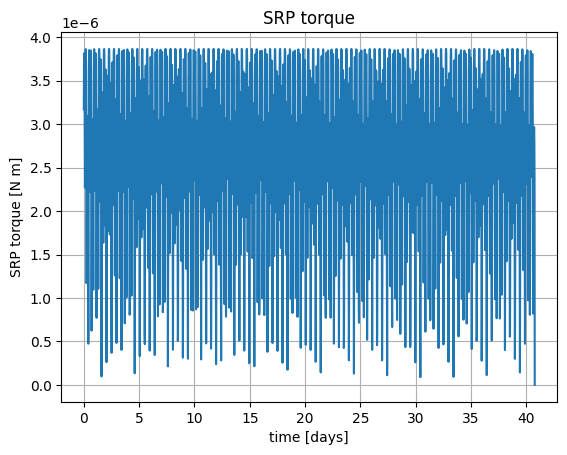

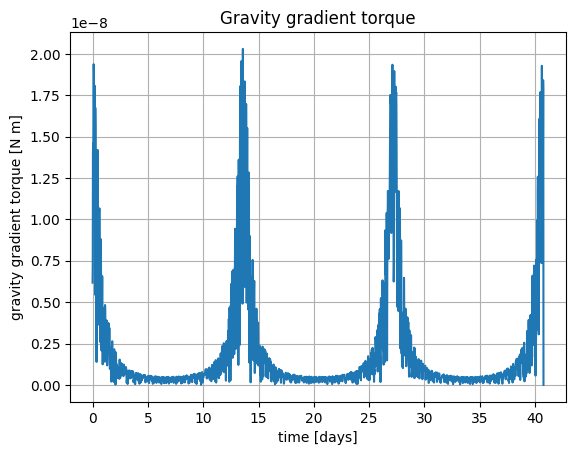

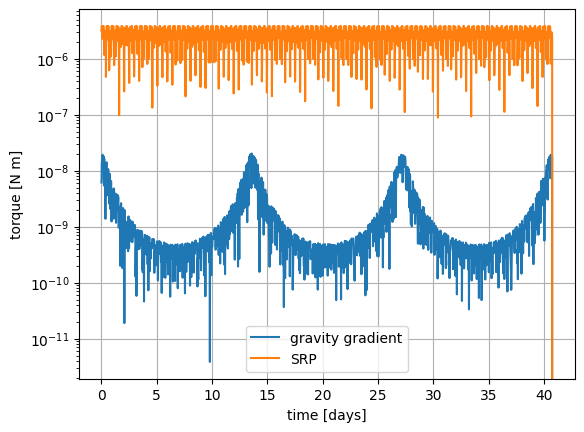

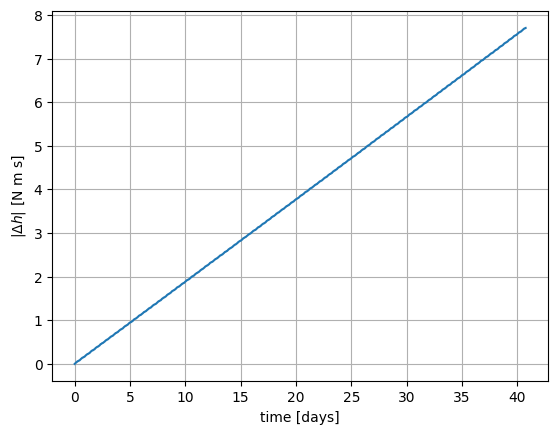

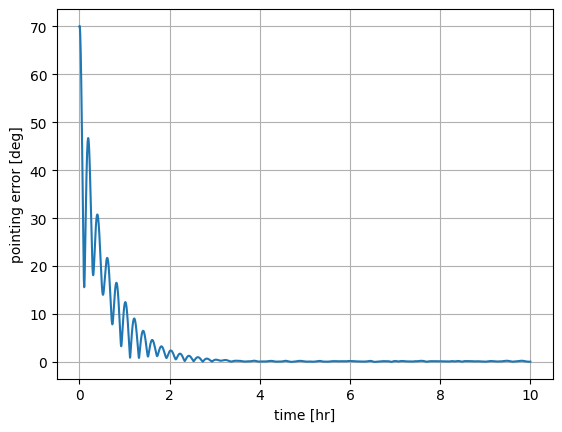

In [93]:
time_days_p2 = np.linspace(0, num_orbits*T_orbit, tau_gg_hist.shape[1]) / 86400
time_hours_p3 = t_eval / 3600

# Problem 2 Plots
plt.figure()
plt.plot(time_days_p2, tau_srp_mag)
plt.xlabel("time [days]")
plt.ylabel("SRP torque [N m]")
plt.title("SRP torque")
plt.grid(True)

plt.figure()
plt.plot(time_days_p2, tau_gg_mag)
plt.xlabel("time [days]")
plt.ylabel("gravity gradient torque [N m]")
plt.title("Gravity gradient torque")
plt.grid(True)

plt.figure()
plt.semilogy(time_days_p2, tau_gg_mag, label="gravity gradient")
plt.semilogy(time_days_p2, tau_srp_mag, label="SRP")
plt.xlabel("time [days]")
plt.ylabel("torque [N m]")
plt.legend()
plt.grid(True)
plt.savefig('torques.jpg')

plt.figure()
plt.plot(time_days_p2, h_accum_mag)
plt.xlabel("time [days]")
plt.ylabel(r"$|\Delta h|$ [N m s]")
plt.grid(True)
plt.savefig('momentum_accumulation.jpg')


# Problem 3 Plots
plt.figure()
plt.plot(time_hours_p3, err_deg_hist)
plt.xlabel("time [hr]")
plt.ylabel("pointing error [deg]")
plt.grid(True)
plt.savefig('pointingerror.jpg')

Max torque: 0.017034404251699827


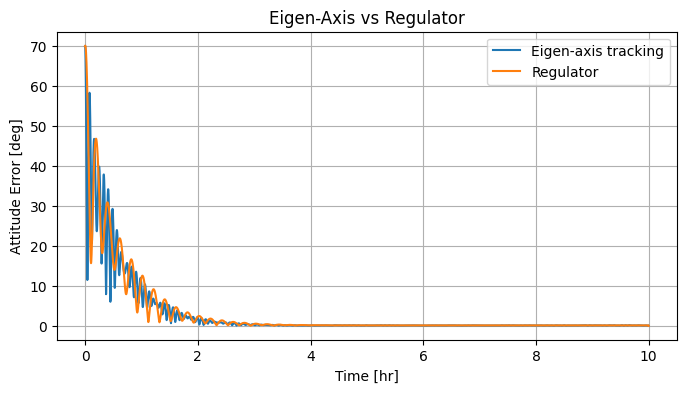

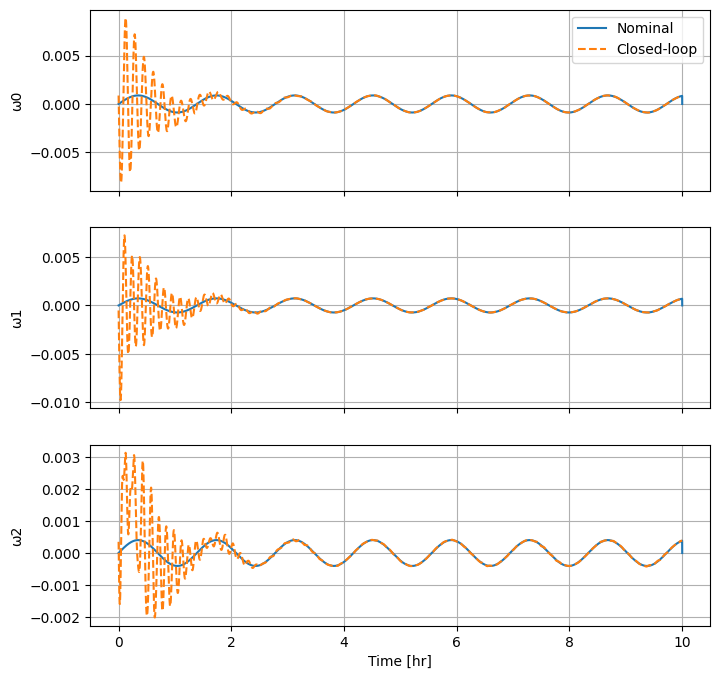

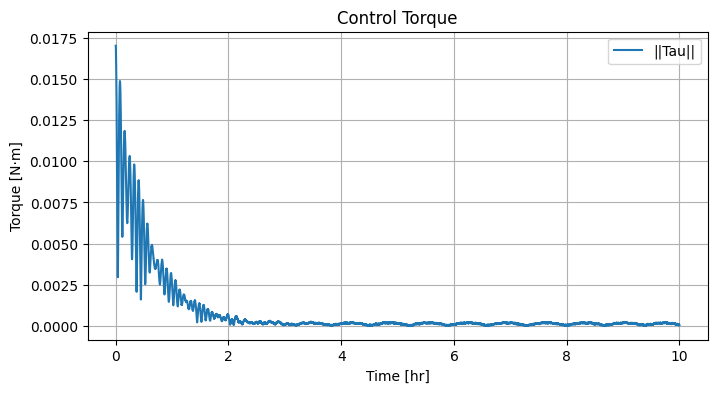

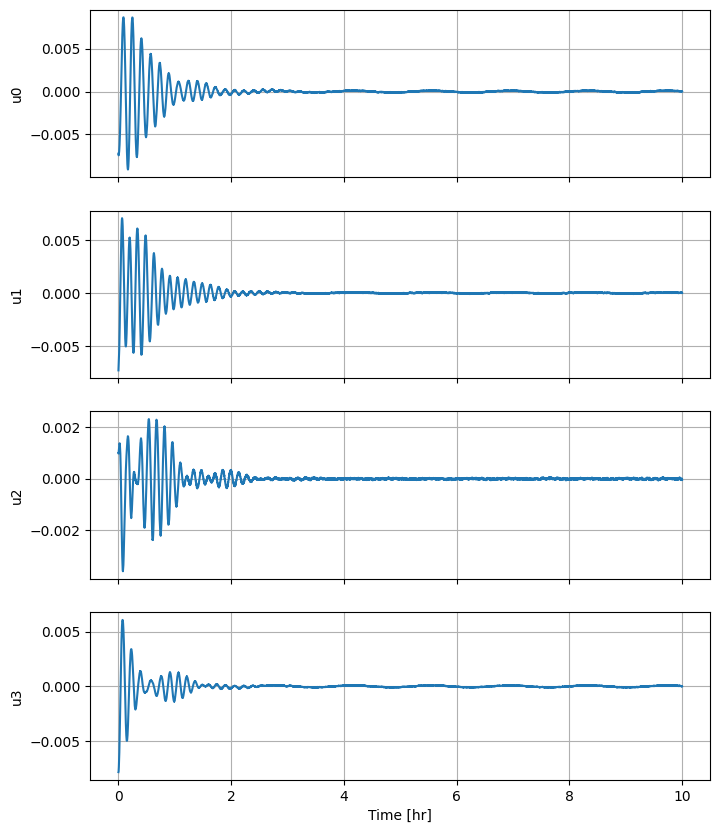

In [94]:

# ---------- Eigen-axis trajectory ----------
def eigen_axis_trajectory(q0, qf, t, T):
    q0 = normalize_quat(q0)
    qf = normalize_quat(qf)

    q_err = qmult(qf, qconj(q0))
    q_err = normalize_quat(q_err)

    if q_err[0] < 0:
        q_err = -q_err

    theta_f = 2 * np.arccos(np.clip(q_err[0], -1, 1))

    if theta_f < 1e-8:
        e = np.array([1.0, 0.0, 0.0])
    else:
        e = q_err[1:4] / np.sin(theta_f/2)

    # Versine
    theta = 0.5 * theta_f * (1 - np.cos(np.pi * t / T))
    theta_dot = 0.5 * theta_f * (np.pi / T) * np.sin(np.pi * t / T)
    theta_ddot = 0.5 * theta_f * (np.pi / T)**2 * np.cos(np.pi * t / T)

    q_nom = np.hstack([np.cos(theta/2), e * np.sin(theta/2)])
    omega_nom = theta_dot * e
    omega_dot_nom = theta_ddot * e

    return normalize_quat(q_nom), omega_nom, omega_dot_nom


# ---------- Inverse dynamics ----------
def inverse_dynamics(omega, omega_dot):
    return J @ omega_dot + np.cross(omega, J @ omega)


# ---------- Tracking controller ----------
def tracking_controller(q_hat, w_hat, q_nom, w_nom, wdot_nom):
    q_err = qmult(qconj(q_nom), q_hat)
    q_err = normalize_quat(q_err)

    if q_err[0] < 0:
        q_err = -q_err

    e = q_err[1:4]

    Kp = 0.03
    Kd = 0.15

    tau_ff = inverse_dynamics(w_nom, wdot_nom)

    return tau_ff - Kp*e - Kd*(w_hat - w_nom)


# ---------- Regulator controller ----------
def regulator_controller(x):
    q = normalize_quat(x[0:4])
    w = x[4:7]

    kp = 0.005
    kd = 0.12

    phi = logq(q)

    return -kp*phi - kd*w


# ---------- Eigen-axis simulation with MEKF ----------
def simulate_eigenaxis_mekf(x0, qf, Tmaneuver):

    x = np.zeros((7, N))
    xfilt = np.zeros((7, N))

    q_nom_hist = np.zeros((4, N))
    w_nom_hist = np.zeros((3, N))

    tau_hist = np.zeros((3, N))
    u_hist = np.zeros((4, N))
    err_hist = np.zeros(N)

    x[:,0] = x0
    xfilt[:,0] = x0

    beta_true = np.zeros(3)
    P = np.eye(6)*0.01

    y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(x[:,0], beta_true)

    for k in range(N-1):
        t = t_eval[k]
        r_I = r_hist[:,k]

        # Nominal trajectory
        q_nom, w_nom, wdot_nom = eigen_axis_trajectory(x0[0:4], qf, t, Tmaneuver)
        q_nom_hist[:,k] = q_nom
        w_nom_hist[:,k] = w_nom

        # Estimated state
        x_est = mekf_control_state(xfilt[:,k], ygyro)
        q_hat = x_est[0:4]
        w_hat = x_est[4:7]

        # Control
        tau_cmd = tracking_controller(q_hat, w_hat, q_nom, w_nom, wdot_nom)
        u = steering(x_est, tau_cmd)
        tau = Bw(x_est) @ u

        # Propagate dynamics
        x[:,k+1] = rkstep(x[:,k], u, r_I, dt)

        # Measurements + MEKF update
        y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(x[:,k+1], beta_true)
        xfilt[:,k+1], P = mekf_step(xfilt[:,k], P, ygyro, y_st, y_sun)

        # Logs
        tau_hist[:,k] = tau
        u_hist[:,k] = u

        q_err = qmult(qconj(q_nom), x[0:4,k])
        err_hist[k] = attitude_error_deg(q_err)

    return x, q_nom_hist, w_nom_hist, tau_hist, u_hist, err_hist


# ---------- Regulator simulation ----------
def simulate_regulator(x0):
    x = np.zeros((7, N))
    err = np.zeros(N)

    x[:,0] = x0

    for k in range(N-1):
        r_I = r_hist[:,k]

        tau = regulator_controller(x[:,k])
        u = steering(x[:,k], tau)

        x[:,k+1] = rkstep(x[:,k], u, r_I, dt)

        err[k] = attitude_error_deg(x[0:4,k])

    return x, err



# ---------- RUN 180° MANEUVER ----------


axis = np.array([1.0, 1.0, 0.5])
axis /= np.linalg.norm(axis)
qf = expq(0.5 * np.pi * axis)

Tmaneuver = 2500  # adjust to satisfy torque limits

x_eig, q_nom, w_nom, tau_eig, u_eig, err_eig = simulate_eigenaxis_mekf(x0_p3, qf, Tmaneuver)
x_reg, err_reg = simulate_regulator(x0_p3)

time_hr = t_eval / 3600


# ---------- PLOTS ----------

# Attitude error comparison
plt.figure(figsize=(8,4))
plt.plot(time_hr, err_eig, label="Eigen-axis tracking")
plt.plot(time_hr, err_reg, label="Regulator")
plt.xlabel("Time [hr]")
plt.ylabel("Attitude Error [deg]")
plt.title("Eigen-Axis vs Regulator")
plt.legend()
plt.grid(True)

# Angular velocity
fig, axs = plt.subplots(3, 1, figsize=(8,8), sharex=True)
for i in range(3):
    axs[i].plot(time_hr, w_nom[i,:], label="Nominal")
    axs[i].plot(time_hr, x_eig[4+i,:], '--', label="Closed-loop")
    axs[i].set_ylabel(f"ω{i}")
    axs[i].grid(True)
axs[0].legend()
axs[-1].set_xlabel("Time [hr]")

# Control torque
tau_mag = np.linalg.norm(tau_eig[:, :-1], axis=0)

plt.figure(figsize=(8,4))
plt.plot(time_hr[:-1], tau_mag, label="||Tau||")
plt.xlabel("Time [hr]")
plt.ylabel("Torque [N·m]")
plt.title("Control Torque")
plt.legend()
plt.grid(True)

# Actuator inputs
fig, axs = plt.subplots(u_eig.shape[0], 1, figsize=(8,10), sharex=True)
for i in range(u_eig.shape[0]):
    axs[i].plot(time_hr[:-1], u_eig[i,:-1])
    axs[i].set_ylabel(f"u{i}")
    axs[i].grid(True)
axs[-1].set_xlabel("Time [hr]")

# ---------- CHECK ----------
print("Max torque:", np.max(tau_mag))

In [95]:
# ============================================================
# Sequential Slew Targets
# ============================================================

def make_90deg_targets():

    q_identity = np.array([1.0, 0.0, 0.0, 0.0])

    qx90 = expq(0.5 * np.radians(90) * np.array([1,0,0]))
    qy90 = expq(0.5 * np.radians(90) * np.array([0,1,0]))
    qz90 = expq(0.5 * np.radians(90) * np.array([0,0,1]))

    targets = [
        qx90,
        qmult(qy90, qx90),
        qmult(qz90, qmult(qy90, qx90)),
        qmult(qx90, qmult(qz90, qmult(qy90, qx90)))
    ]

    return [normalize_quat(q) for q in targets]


# ============================================================
# Settling Time Detector
# ============================================================

def compute_settling_time(err, time, tol_deg=0.5):

    for i in range(len(err)):

        if np.all(err[i:] < tol_deg):
            return time[i]

    return np.nan


# ============================================================
# Sequential Eigen-Axis Slew Simulation
# ============================================================

def simulate_sequential_slews(x0, targets, Tmaneuver=1200):

    x = np.zeros((7, N))
    xfilt = np.zeros((7, N))

    tau_hist = np.zeros((3, N))
    err_hist = np.zeros(N)

    target_index_hist = np.zeros(N)

    x[:,0] = x0
    xfilt[:,0] = x0

    beta_true = np.zeros(3)
    P = np.eye(6) * 0.01

    y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(
        x[:,0],
        beta_true
    )

    current_target = 0

    q_start = x0[0:4]
    q_goal = targets[current_target]

    t_segment_start = 0.0

    settling_times = []

    settled = False

    for k in range(N-1):

        t = t_eval[k]
        r_I = r_hist[:,k]

        # --------------------------------------------
        # Time within current maneuver
        # --------------------------------------------

        t_local = t - t_segment_start

        if t_local > Tmaneuver:
            t_local = Tmaneuver

        # --------------------------------------------
        # Nominal trajectory
        # --------------------------------------------

        q_nom, w_nom, wdot_nom = eigen_axis_trajectory(
            q_start,
            q_goal,
            t_local,
            Tmaneuver
        )

        # --------------------------------------------
        # Estimated state
        # --------------------------------------------

        x_est = mekf_control_state(xfilt[:,k], ygyro)

        q_hat = x_est[0:4]
        w_hat = x_est[4:7]

        # --------------------------------------------
        # Tracking controller
        # --------------------------------------------

        tau_cmd = tracking_controller(
            q_hat,
            w_hat,
            q_nom,
            w_nom,
            wdot_nom
        )

        u = steering(x_est, tau_cmd)

        # --------------------------------------------
        # Propagate spacecraft
        # --------------------------------------------

        x[:,k+1] = rkstep(
            x[:,k],
            u,
            r_I,
            dt,
            include_control=True,
            include_gg=True,
            include_srp=True
        )

        # --------------------------------------------
        # Sensor generation
        # --------------------------------------------

        y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(
            x[:,k+1],
            beta_true
        )

        # --------------------------------------------
        # MEKF update
        # --------------------------------------------

        xfilt[:,k+1], P = mekf_step(
            xfilt[:,k],
            P,
            ygyro,
            y_st,
            y_sun
        )

        # --------------------------------------------
        # Tracking error
        # --------------------------------------------

        q_err = qmult(qconj(q_nom), q_hat)
        err_deg = attitude_error_deg(q_err)

        err_hist[k] = err_deg

        tau_hist[:,k] = tau_cmd

        target_index_hist[k] = current_target

        # --------------------------------------------
        # Settling logic
        # --------------------------------------------

        if (t_local >= Tmaneuver):

            w_mag = np.linalg.norm(x[4:7,k])

            if err_deg < 0.5 and w_mag < np.radians(0.05):

                if not settled:

                    settling_times.append(t)
                    settled = True

                if current_target < len(targets)-1:

                    current_target += 1

                    q_start = x[0:4,k]
                    q_goal = targets[current_target]

                    t_segment_start = t

                    settled = False

    return {
        "x": x,
        "xfilt": xfilt,
        "tau": tau_hist,
        "err": err_hist,
        "target_index": target_index_hist,
        "settling_times": settling_times
    }

/var/folders/6b/jk7y7cc50n9d1qq_9y5c779r0000gn/T/ipykernel_6309/947938661.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


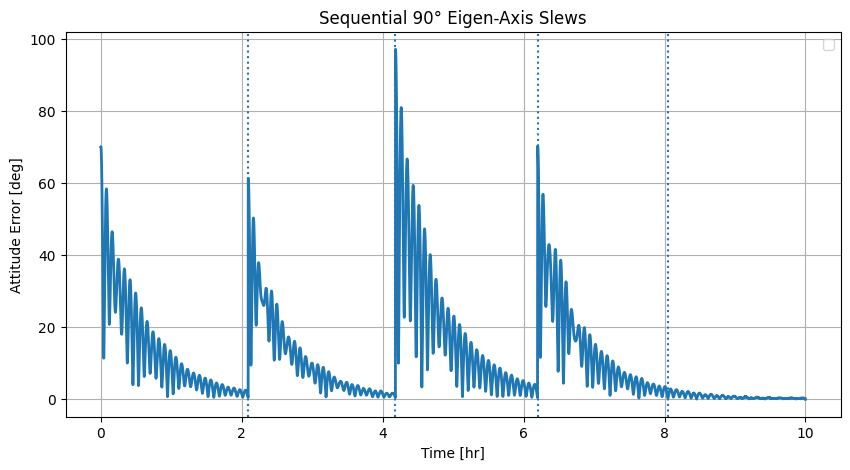

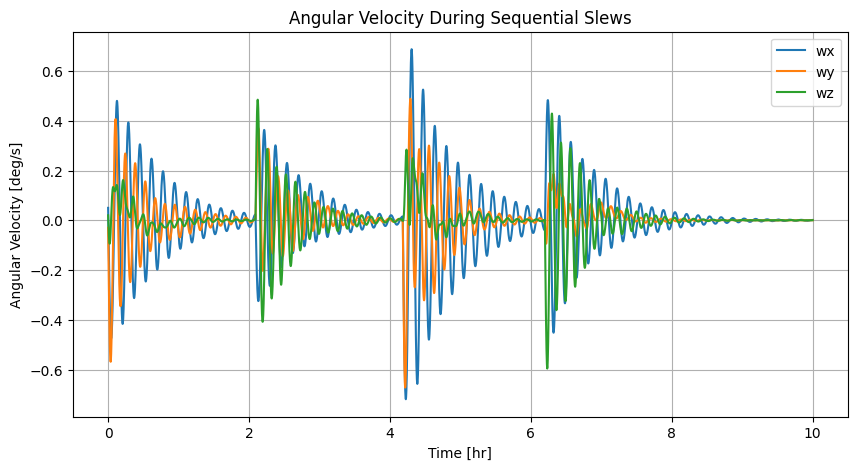

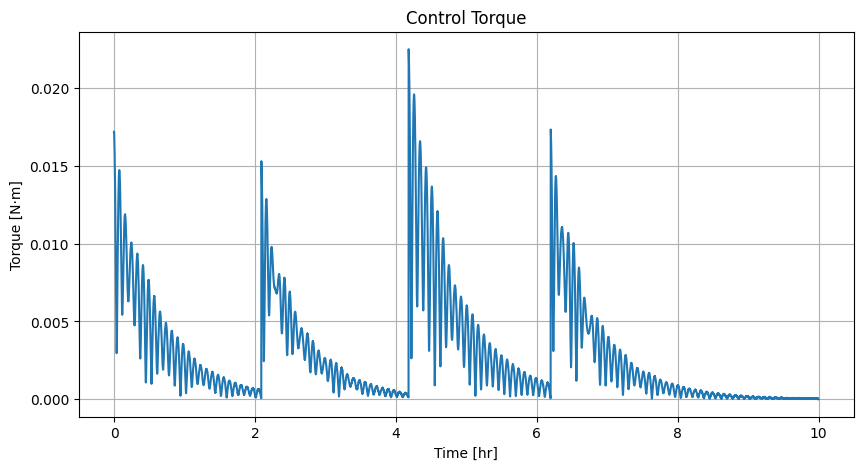

Settling times [hr]:
[2.09027778 4.18055556 6.19722222 8.04583333]


In [96]:
# ============================================================
# RUN SEQUENTIAL 90-DEGREE SLEWS
# ============================================================

targets = make_90deg_targets()

slew_results = simulate_sequential_slews(
    x0_p3,
    targets,
    Tmaneuver=5000
)

x_seq = slew_results["x"]
err_seq = slew_results["err"]
tau_seq = slew_results["tau"]
settling_times = slew_results["settling_times"]

time_hr = t_eval / 3600

# ============================================================
# ATTITUDE ERROR
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(time_hr, err_seq, linewidth=2)

for ts in settling_times:
    plt.axvline(ts/3600, linestyle=':')

plt.xlabel("Time [hr]")
plt.ylabel("Attitude Error [deg]")
plt.title("Sequential 90° Eigen-Axis Slews")
plt.grid(True)
plt.legend()

# ============================================================
# ANGULAR VELOCITY
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(time_hr, np.degrees(x_seq[4,:]), label='wx')
plt.plot(time_hr, np.degrees(x_seq[5,:]), label='wy')
plt.plot(time_hr, np.degrees(x_seq[6,:]), label='wz')

plt.xlabel("Time [hr]")
plt.ylabel("Angular Velocity [deg/s]")
plt.title("Angular Velocity During Sequential Slews")
plt.grid(True)
plt.legend()

# ============================================================
# CONTROL TORQUE
# ============================================================

tau_mag = np.linalg.norm(tau_seq, axis=0)

plt.figure(figsize=(10,5))

plt.plot(time_hr, tau_mag)

plt.xlabel("Time [hr]")
plt.ylabel("Torque [N·m]")
plt.title("Control Torque")
plt.grid(True)

plt.show()

print("Settling times [hr]:")
print(np.array(settling_times)/3600)

/var/folders/6b/jk7y7cc50n9d1qq_9y5c779r0000gn/T/ipykernel_6309/586520962.py:47: RuntimeWarning: invalid value encountered in divide
  q = q / np.linalg.norm(q)


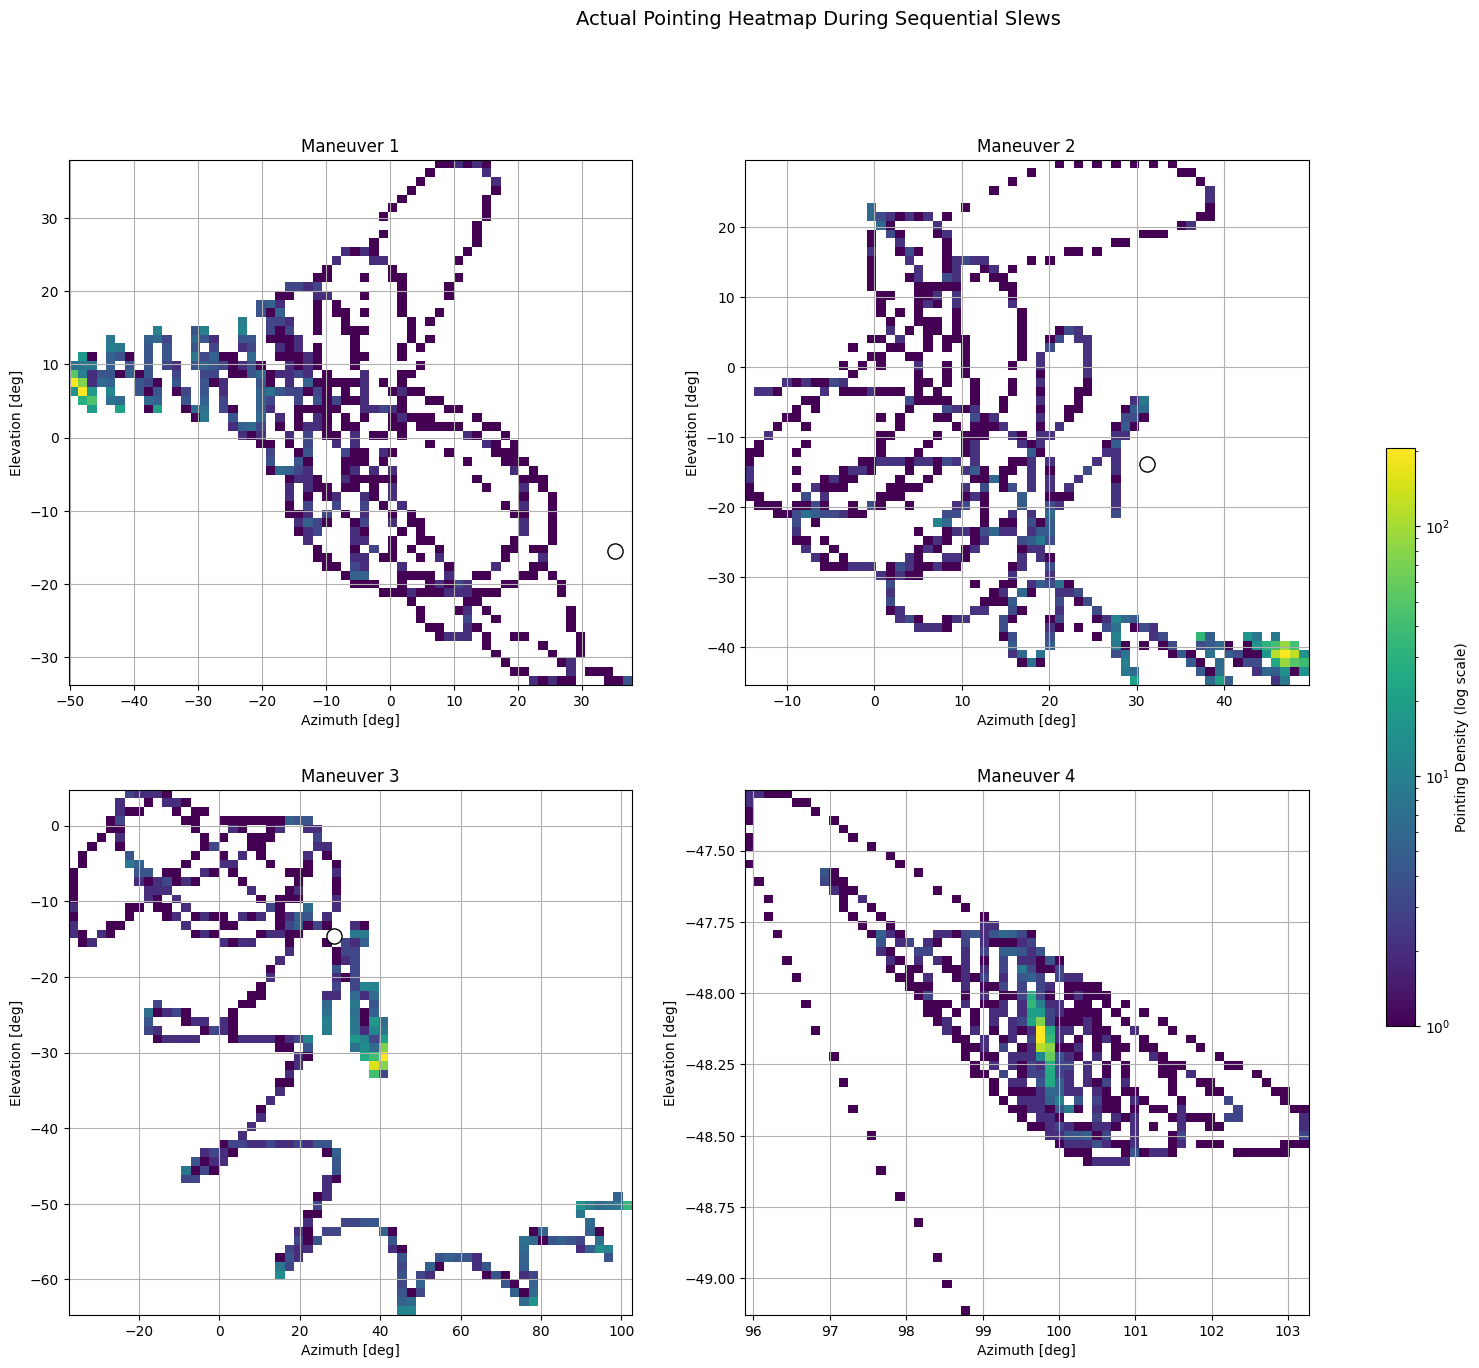

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# CONFIG
# ============================================================

boresight = np.array([1.0, 0.0, 0.0])

def vec_to_az_el(v):
    v = v / np.linalg.norm(v)

    az = np.degrees(np.arctan2(v[1], v[0]))
    el = np.degrees(np.arcsin(np.clip(v[2], -1.0, 1.0)))

    return az, el


# ============================================================
# EXTRACT POINTING HISTORY
# ============================================================

def compute_pointing(q_hist):
    N = q_hist.shape[1]

    az = np.zeros(N)
    el = np.zeros(N)

    for k in range(N):
        C = Q(q_hist[:, k])
        v = C @ boresight
        az[k], el[k] = vec_to_az_el(v)

    return az, el


# TRUE + NOMINAL POINTING
az_true, el_true = compute_pointing(x_seq[0:4, :])
az_nom, el_nom = compute_pointing(q_nom)


# ============================================================
# SPLIT INTO 4 MANEUVERS
# ============================================================

N = len(t_eval)
segments = 4
idx_split = np.array_split(np.arange(N), segments)


# ============================================================
# PLOT
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(20, 15))
axs = axs.ravel()

for i in range(4):

    idx = idx_split[i]

    ax = axs[i]

    h = ax.hist2d(
        az_true[idx],
        el_true[idx],
        bins=60,
        norm=LogNorm()
    )

    # overlay intended mean pointing
    ax.scatter(
        np.mean(az_nom[idx]),
        np.mean(el_nom[idx]),
        s=120,
        c='white',
        edgecolors='black',
        label=f"Target {i+1}"
    )

    ax.set_title(f"Maneuver {i+1}")
    ax.set_xlabel("Azimuth [deg]")
    ax.set_ylabel("Elevation [deg]")
    ax.grid(True)

# shared colorbar
cbar = fig.colorbar(h[3], ax=axs, shrink=0.5)
cbar.set_label("Pointing Density (log scale)")

plt.suptitle("Actual Pointing Heatmap During Sequential Slews", fontsize=14)
plt.show()